In [ ]:
'''
참고사항

1. google drive에 checkpoint 필요
  ex)
    - checkpoint path: /content/drive/MyDrive/checkpoints/toss.ckpt
'''

In [1]:
!git clone https://github.com/IDEA-Research/TOSS.git

Cloning into 'TOSS'...
remote: Enumerating objects: 218, done.
remote: Counting objects: 100% (218/218), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 218 (delta 49), reused 207 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (218/218), 14.27 MiB | 34.79 MiB/s, done.
Resolving deltas: 100% (49/49), done.


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# !rsync -ah --info=progress2 "/content/drive/MyDrive/checkpoints/toss.ckpt" "/content/TOSS/ckpt/"

In [4]:
requirements = '''
albumentations==2.0.8
opencv-python==4.12.0.88
imageio==2.37.2
imageio-ffmpeg==0.4.2
pytorch-lightning==1.9.5
omegaconf==2.3.0
test-tube>=0.7.5
streamlit==1.12.1
einops==0.8.1
transformers==4.57.3
webdataset==0.2.5
kornia==0.8.2
open_clip_torch==3.2.0
invisible-watermark>=0.1.5
streamlit-drawable-canvas==0.8.0
torchmetrics==1.8.2
timm==1.0.22
addict==2.4.0
yapf==0.32.0
prettytable==3.16.0
safetensors==0.7.0
basicsr==1.4.2
carvekit-colab==4.1.2
peft==0.17.1
setuptools==81.0.0
lpips==0.1.4
wandb==0.24.1
'''

with open('requirements.txt', 'w') as f:
  f.write(requirements)

In [5]:
!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu121
!pip install -r requirements.txt
%cd TOSS/
!git clone https://github.com/openai/CLIP.git
!pip install -e CLIP/

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 76.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 94.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 83.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 111.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

/content/TOSS
Cloning into 'CLIP'...
remote: Enumerating objects: 265, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 265 (delta 2), reused 3 (delta 1), pack-reused 257 (from 2)
Receiving objects: 100% (265/265), 8.87 MiB | 26.88 MiB/s, done.
Resolving deltas: 100% (138/138), done.
Obtaining file:///content/TOSS/CLIP
  Preparing metadata (setup.py) ... done
  Running setup.py develop for clip


In [1]:
%cd /content/TOSS

/content/TOSS


In [2]:
from PIL import Image
import numpy as np
import torchvision.transforms as T

# Load the last checkpoint
import torch
from cldm.toss import TOSS
from cldm.model import load_state_dict
from omegaconf import OmegaConf
from PIL import Image
from torchvision import transforms as T

from ldm.util import instantiate_from_config

config = OmegaConf.load("models/toss_vae.yaml")
model = instantiate_from_config(config.model)

checkpoint_path = "/content/drive/MyDrive/checkpoints/toss.ckpt"
state_dict = torch.load(checkpoint_path, map_location="cpu", weights_only=False)["state_dict"]

model.load_state_dict(state_dict, strict=False)

/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


No module 'xformers'. Proceeding without it.


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/distributed.py:258: LightningDeprecationWarning: `pytorch_lightning.utilities.distributed.rank_zero_only` has been deprecated in v1.8.1 and will be removed in v2.0.0. You can import it from `pytorch_lightning.utilities` instead.
  rank_zero_deprecation(


TOSS: Running in eps-prediction mode
DiffusionWrapper has 863.65 M params.
Keeping EMAs of 724.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


KeyboardInterrupt: 

In [4]:
# TOSS app.py to ipynb
model.cuda()
model.eval()

# source image
img_name = "man_head.png"
src_img = Image.open(f"{img_name}").convert("RGB")

transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    # T.Normalize([0.5]*3, [0.5]*3)  # → [-1,1]
])

src_img = transform(src_img)
src_img = src_img.unsqueeze(0).cuda()
print(src_img.shape)

with torch.no_grad():
    z = model.encode_first_stage(src_img)
    z = model.get_first_stage_encoding(z)
print(z.shape)

print("pose_net in_features:", model.model.diffusion_model.pose_net[0].in_features)

# empty text
txt = [""]

# batch = {
#         "jpg": src_img,
#         "hint": src_img,
#         # 'mask': mask,
#         "delta_pose": delta_pose, # pose from original angle
#         # "subject_id": os.path.basename(sub_path),
#         "txt": txt
#     }

n_samples = 1
prompt_scale = 0.0
img_scale = 1.0
ddim_steps = 50
ddim_eta = 0.0
h = 256
w = 256

import math
def get_T_from_relative(x, y, z, pose_enc="freq")->torch.Tensor:
    """
    Args:
        x: relative polar degree
        y: relative azimuth degree
        z: relative distance

    example:
        (0., -90., 0.): left view
        (0., 90., 0.): right view
        (0., 180., 0.): back view
        (-90., 0., 0.): top view
        (90., 0., 0.): bottom view
    """
    print("POSE_ENC:", pose_enc)
    if pose_enc in ["freq","identity", "vae"]:
        d_T = torch.tensor([math.radians(x), math.radians(y), z])
    elif pose_enc == "zero":
        d_T = torch.tensor([math.radians(x), math.sin(
                math.radians(y)), math.cos(math.radians(y)), z])
    else:
        raise NotImplementedError
    return d_T

# Pose
yaw_deg = -30.0
yaw_rad = math.radians(yaw_deg)
delta_pose = torch.tensor([[0.0, yaw_rad, 0.0]], device='cuda')


# hint
c_cat = src_img

# text
uc_cross = model.get_unconditional_conditioning(n_samples)
c = model.get_learned_conditioning(txt)
# camera pose
# delta_pose = T[None, :].repeat(n_samples, 1).to(c.device)
# concat for concat pipline
in_concat = model.encode_first_stage(((src_img*2-1).to(c.device))).mode().detach()


cond = {}
cond['delta_pose'] = delta_pose
cond['c_crossattn'] = [c]
cond['c_concat'] = [c_cat]
cond['in_concat'] = [in_concat]

# uc2 for prompt
uc2 = {}
uc2['delta_pose'] = delta_pose
uc2['c_crossattn'] = [uc_cross]
uc2['c_concat'] = [c_cat]
uc2['in_concat'] = [in_concat]

# uc for image
uc = {}
uc['delta_pose'] = delta_pose
uc['c_crossattn'] = [uc_cross]
uc['c_concat'] = [c_cat]
uc['in_concat'] = [in_concat*0]

from ldm.models.diffusion.ddim import DDIMSampler
from torchvision.utils import save_image

sampler = DDIMSampler(model)

shape = [4, h // 8, w // 8]
x_T = torch.randn(in_concat.shape, device=c.device)
samples_ddim, _ = sampler.sample(S=ddim_steps,
                                conditioning=cond,
                                batch_size=n_samples,
                                shape=shape,
                                verbose=False,
                                unconditional_guidance_scale=img_scale,
                                unconditional_conditioning=uc,
                                unconditional_guidance_scale2=prompt_scale,
                                unconditional_conditioning2=uc2,
                                eta=ddim_eta,
                                x_T=x_T)


print(samples_ddim.shape)
x_samples_ddim = model.decode_first_stage(samples_ddim)

out = torch.clamp((x_samples_ddim + 1.0) / 2.0, min=0.0, max=1.0).cpu()

print(out.shape)

torch.Size([1, 3, 256, 256])
torch.Size([1, 4, 32, 32])
pose_net in_features: 51
Data shape for DDIM sampling is (1, 4, 32, 32), eta 0.0
Running DDIM Sampling with 50 timesteps


DDIM Sampler: 100%|██████████| 50/50 [00:03<00:00, 14.20it/s]


torch.Size([1, 4, 32, 32])
torch.Size([1, 3, 256, 256])


In [7]:
"""
TOSS inference API for notebooks — same sampling pipeline as app.py (no Gradio, no CLI).

Example:
    from inference import TossInference
    runner = TossInference(resume_path="ckpt/toss.ckpt")
    out = runner.generate("input.png", prompt="a red shoe", dy=-90)
    out = runner.generate(pil_image, prompt="", dx=0, dy=0, dz=0)
"""
from __future__ import annotations

from pathlib import Path
from types import SimpleNamespace
from typing import Union

import numpy as np
import torch
from einops import rearrange
from omegaconf import OmegaConf
from PIL import Image
from pytorch_lightning import seed_everything
from torchvision import transforms

from ldm.models.diffusion.ddim import DDIMSampler

from app import get_T_from_relative, preprocess_image, sample_model

def load_model(device, _hparams, sd_locked, only_mid_control, cfgs):
    model = instantiate_from_config(cfgs.model)

    # Load the state dict
    state_dict = load_state_dict(_hparams.resume_path, location='cpu')

    # --- FIX START ---
    # Remove the problematic key if it exists
    key_to_remove = "cond_stage_model.transformer.text_model.embeddings.position_ids"
    if key_to_remove in state_dict:
        print(f"Removing {key_to_remove} from state_dict to match model structure.")
        del state_dict[key_to_remove]
    # --- FIX END ---

    model.load_state_dict(state_dict, strict=False) # Adding strict=False is a safe backup

    # reweight noise scheduler
    if _hparams.register_scheduler:
        model.register_schedule(given_betas=None, beta_schedule="linear", timesteps=1000, linear_start=0.00085, linear_end=0.016)

    model.learning_rate = _hparams.lr
    model.sd_locked = sd_locked
    model.only_mid_control = only_mid_control
    model = model.to(device)
    model.eval()
    return model

ImageInput = Union[str, Path, Image.Image, np.ndarray]


def _to_pil_rgba(image: ImageInput) -> Image.Image:
    if isinstance(image, (str, Path)):
        return Image.open(image).convert("RGBA")
    if isinstance(image, Image.Image):
        return image.convert("RGBA")
    if isinstance(image, np.ndarray):
        arr = image
        if arr.dtype != np.uint8:
            arr = np.clip(arr, 0.0, 1.0)
            if arr.max() <= 1.0:
                arr = (arr * 255.0).astype(np.uint8)
            else:
                arr = arr.astype(np.uint8)
        if arr.ndim == 2:
            raise ValueError("grayscale numpy arrays are not supported; use RGB/RGBA")
        if arr.shape[-1] == 4:
            return Image.fromarray(arr, mode="RGBA")
        if arr.shape[-1] == 3:
            return Image.fromarray(arr, mode="RGB").convert("RGBA")
        raise ValueError(f"expected HxWx3 or HxWx4 array, got shape {arr.shape}")
    raise TypeError(f"unsupported image type: {type(image)}")

class TossInference:
    """Load TOSS once, then call ``generate`` with varying inputs (notebook-friendly)."""

    def __init__(
        self,
        model_cfg: str | Path = "models/toss_vae.yaml",
        resume_path: str | Path = "/content/drive/MyDrive/checkpoints/toss.ckpt",
        *,
        device: torch.device | str | None = None,
        gpu: int = 0,
        register_scheduler: bool = False,
        lr: float = 1e-4,
        seed: int = 40,
        sd_locked: bool = True,
        only_mid_control: bool = False,
        use_ema_scope: bool = True,
        pose_enc: str = "freq",
        h: int = 256,
        w: int = 256,
    ):
        """
        Args:
            model_cfg: YAML defining the model (e.g. ``models/toss_vae.yaml``).
            resume_path: Checkpoint with ``state_dict`` (e.g. ``ckpt/toss.ckpt``).
            device: Explicit device; if None, uses ``cuda:{gpu}`` when available.
            gpu: CUDA index when ``device`` is None.
            register_scheduler: Passed through to ``load_model`` (same as training flag).
            lr: Required by ``load_model``; not used during inference.
            seed: Fixed at init; call ``set_seed`` to change between runs.
            use_ema_scope / pose_enc / h / w: Defaults for ``generate`` (overridable per call).
        """
        seed_everything(seed, workers=True)
        if device is None:
            self.device = torch.device(
                f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"
            )
        else:
            self.device = torch.device(device)

        hparams = SimpleNamespace(
            resume_path=str(resume_path),
            register_scheduler=register_scheduler,
            lr=lr,
        )
        cfgs = OmegaConf.load(str(model_cfg))
        self.model = load_model(
            self.device, hparams, sd_locked, only_mid_control, cfgs
        )
        self.sampler = DDIMSampler(self.model)

        self._default_use_ema_scope = use_ema_scope
        self._default_pose_enc = pose_enc
        self._default_h = h
        self._default_w = w

    def set_seed(self, seed: int) -> None:
        """Call between ``generate`` runs for reproducible DDIM noise."""
        seed_everything(seed, workers=True)

    @torch.no_grad()
    def generate(
        self,
        image: ImageInput,
        prompt: str = "",
        dx: float = 0.0,
        dy: float = 0.0,
        dz: float = 0.0,
        *,
        pose_enc: str | None = None,
        h: int | None = None,
        w: int | None = None,
        precision: str = "fp32",
        n_samples: int = 1,
        use_ema_scope: bool | None = None,
        ddim_steps: int = 75,
        ddim_eta: float = 1.0,
        prompt_scale: float = 5.0,
        img_scale: float = 3.0,
        img_ucg: float = 0.05,
    ) -> Image.Image:
        """
        Novel view for one image (same logic as ``app.generate_loop_views`` / ``sample_model``).

        Args:
            image: Path, ``PIL.Image``, or ``HxWx3`` / ``HxWx4`` numpy array (float or uint8).
            prompt: Text conditioning (empty string allowed).
            dx, dy, dz: Relative pose in degrees / distance (see ``app.get_T_from_relative``).
        """
        h = self._default_h if h is None else h
        w = self._default_w if w is None else w
        pose_enc = self._default_pose_enc if pose_enc is None else pose_enc
        if use_ema_scope is None:
            use_ema_scope = self._default_use_ema_scope

        cond_im_pil = _to_pil_rgba(image)
        cond_im = preprocess_image(cond_im_pil)
        cond_im = transforms.ToTensor()(cond_im).unsqueeze(0).to(self.device)
        cond_im = transforms.functional.resize(cond_im, [h, w])

        T = get_T_from_relative(dx, dy, dz, pose_enc)
        x_samples = sample_model(
            cond_im,
            self.model,
            self.sampler,
            precision=precision,
            h=h,
            w=w,
            ddim_steps=ddim_steps,
            n_samples=n_samples,
            prompt_scale=prompt_scale,
            img_scale=img_scale,
            ddim_eta=ddim_eta,
            T=T,
            use_ema_scope=use_ema_scope,
            prompt=prompt,
            img_ucg=img_ucg,
        )
        assert x_samples.shape[0] == 1
        out = x_samples[0].cpu().numpy()
        out = 255.0 * rearrange(out, "c h w -> h w c")
        return Image.fromarray(out.astype(np.uint8))

In [8]:
toss = TossInference()

INFO:lightning_fabric.utilities.seed:Global seed set to 40


TOSS: Running in eps-prediction mode
DiffusionWrapper has 863.65 M params.
Keeping EMAs of 724.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels


/content/TOSS/cldm/model.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = get_state_dict(torch.load(ckpt_path, map_location=torch.device(location)))


Loaded state_dict from [/content/drive/MyDrive/checkpoints/toss.ckpt]
Removing cond_stage_model.transformer.text_model.embeddings.position_ids from state_dict to match model structure.


In [10]:
img_name = "man_head.png"
src_img = Image.open(f"{img_name}").convert("RGBA")

image = toss.generate(
    image=src_img,
    prompt="",
    dy=20.0,
)

Sampling...: Switched to EMA weights
Data shape for DDIM sampling is (1, 4, 32, 32), eta 1.0
Running DDIM Sampling with 77 timesteps


DDIM Sampler: 100%|██████████| 77/77 [00:09<00:00,  8.09it/s]

torch.Size([1, 4, 32, 32])
Sampling...: Restored training weights


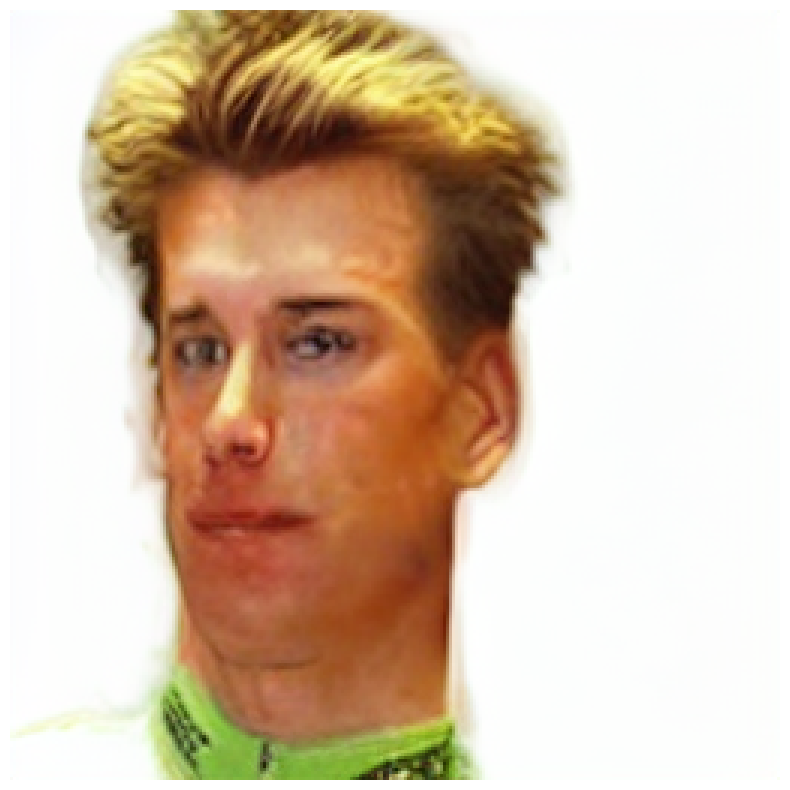

In [11]:
import matplotlib.pyplot as plt

# 1. Take the first image in the batch: [3, H, W]
# 2. Permute dimensions to: [H, W, 3]
# img_to_show = out[0].permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off') # Hide the x/y coordinates
plt.show()

In [ ]:
!python app.py

2026-03-29 11:13:42.610948: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-29 11:13:42.629982: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774782822.651917    4762 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774782822.658599    4762 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774782822.675548    4762 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
from share import *
import gradio as gr
import cv2
import PIL
import imageio
from functools import partial
from cldm.model import load_state_dict
from ldm.util import instantiate_from_config
from ldm.models.diffusion.ddim import DDIMSampler

import torch
from torchvision import transforms
from torch import autocast
import numpy as np
import math
from einops import rearrange
from pathlib import Path
import os, shutil
from omegaconf import OmegaConf
from contextlib import nullcontext
from PIL import Image
from einops import rearrange

# configure
from opt import get_opts
from pytorch_lightning import seed_everything

seed_everything(40)
device_idx = 0
device = torch.device(f'cuda:{device_idx}' if torch.cuda.is_available() else 'cpu')

class BackgroundRemoval:
    def __init__(self, device='cuda'):
        from carvekit.api.high import HiInterface
        self.interface = HiInterface(
            object_type="object",  # Can be "object" or "hairs-like".
            batch_size_seg=5,
            batch_size_matting=1,
            device=device,
            seg_mask_size=640,  # Use 640 for Tracer B7 and 320 for U2Net
            matting_mask_size=2048,
            trimap_prob_threshold=231,
            trimap_dilation=30,
            trimap_erosion_iters=5,
            fp16=True,
        )

    @torch.no_grad()
    def __call__(self, image):
        # image: [H, W, 3] array in [0, 255].
        image = Image.fromarray(image)
        image = self.interface([image])[0]
        image = np.array(image)
        return image

def segment(mask_predictor, image=None, image_path=None):
    if image is None:
        assert image_path is not None, 'image_path is None and image is None'
        image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if isinstance(image, PIL.Image.Image):
        image = np.array(image)
    if image.shape[-1] == 4:
        image = cv2.cvtColor(image, cv2.COLOR_BGRA2RGB)
    else:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    rgba = mask_predictor(image)  # [H, W, 4]
    return Image.fromarray(cv2.cvtColor(rgba, cv2.COLOR_RGBA2BGRA))

def load_model_from_config(config, ckpt, device, verbose=True):
    print(f'Loading model from {ckpt}')
    pl_sd = torch.load(ckpt, map_location='cpu')
    if 'global_step' in pl_sd:
        print(f'Global Step: {pl_sd["global_step"]}')
    sd = pl_sd['state_dict']
    model = instantiate_from_config(config.model)
    m, u = model.load_state_dict(sd, strict=False)
    if len(m) > 0 and verbose:
        print('missing keys:')
        print(m)
    if len(u) > 0 and verbose:
        print('unexpected keys:')
        print(u)

    model.to(device)
    model.eval()
    return model

@torch.no_grad()
def sample_model(input_im, model, sampler, precision, h, w, ddim_steps, n_samples, prompt_scale, img_scale,
                 ddim_eta, T, use_ema_scope=False, prompt=None, img_ucg=0.05):
    precision_scope = autocast if precision == 'autocast' else nullcontext
    ema_scope = model.ema_scope if use_ema_scope else nullcontext
    with precision_scope('cuda'):
        with ema_scope('Sampling...'):
            # hint
            c_cat = input_im
            # text
            uc_cross = model.get_unconditional_conditioning(n_samples)
            c = model.get_learned_conditioning(prompt)
            # camera pose
            delta_pose = T[None, :].repeat(n_samples, 1).to(c.device)
            # concat for concat pipline
            in_concat = model.encode_first_stage(((input_im*2-1).to(c.device))).mode().detach()

            cond = {}
            cond['delta_pose'] = delta_pose
            cond['c_crossattn'] = [c]
            cond['c_concat'] = [c_cat]
            cond['in_concat'] = [in_concat]

            # uc2 for prompt
            uc2 = {}
            uc2['delta_pose'] = delta_pose
            uc2['c_crossattn'] = [uc_cross]
            uc2['c_concat'] = [c_cat]
            uc2['in_concat'] = [in_concat]

            # uc for image
            uc = {}
            uc['delta_pose'] = delta_pose
            uc['c_crossattn'] = [uc_cross]
            uc['c_concat'] = [c_cat]
            uc['in_concat'] = [in_concat*0]

            shape = [4, h // 8, w // 8]
            x_T = torch.randn(in_concat.shape, device=c.device)
            samples_ddim, _ = sampler.sample(S=ddim_steps,
                                             conditioning=cond,
                                             batch_size=n_samples,
                                             shape=shape,
                                             verbose=False,
                                             unconditional_guidance_scale=img_scale,
                                             unconditional_conditioning=uc,
                                             unconditional_guidance_scale2=prompt_scale,
                                             unconditional_conditioning2=uc2,
                                             eta=ddim_eta,
                                             x_T=x_T)
            print(samples_ddim.shape)
            x_samples_ddim = model.decode_first_stage(samples_ddim)
            return torch.clamp((x_samples_ddim + 1.0) / 2.0, min=0.0, max=1.0).cpu()

def load_model_from_config(config, ckpt, device, verbose=False):
    print(f'Loading model from {ckpt}')
    pl_sd = torch.load(ckpt, map_location='cpu')
    if 'global_step' in pl_sd:
        print(f'Global Step: {pl_sd["global_step"]}')
    sd = pl_sd['state_dict']
    model = instantiate_from_config(config.model)
    m, u = model.load_state_dict(sd, strict=False)
    if len(m) > 0 and verbose:
        print('missing keys:')
        print(m)
    if len(u) > 0 and verbose:
        print('unexpected keys:')
        print(u)

    model.to(device)
    model.eval()
    return model

def get_model(config, device, ckpt='105000.ckpt'):
    config = OmegaConf.load(config)
    print('Instantiating LatentDiffusion...')
    model = load_model_from_config(config, ckpt, device)
    print('Done.')
    return model

def preprocess_image(input_im):
    '''
    :param input_im (PIL Image).
    :return input_im (H, W, 3) array in [0, 1].
    '''
    input_im = input_im.resize([256, 256], Image.Resampling.LANCZOS)
    input_im = np.asarray(input_im, dtype=np.float32) / 255.0
    # (H, W, 4) array in [0, 1].

    # old method: thresholding background, very important
    # input_im[input_im[:, :, -1] <= 0.9] = [1., 1., 1., 1.]

    # new method: apply correct method of compositing to avoid sudden transitions / thresholding
    # (smoothly transition foreground to white background based on alpha values)
    if input_im.shape[-1] == 4:
        alpha = input_im[:, :, 3:4]
        white_im = np.ones_like(input_im)
        input_im = alpha * input_im + (1.0 - alpha) * white_im

    input_im = input_im[:, :, 0:3]
    # (H, W, 3) array in [0, 1].

    return input_im

# %%
def cartesian_to_spherical(xyz):
    ptsnew = np.hstack((xyz, np.zeros(xyz.shape)))
    xy = xyz[:,0]**2 + xyz[:,1]**2
    z = np.sqrt(xy + xyz[:,2]**2)
    theta = np.arctan2(np.sqrt(xy), xyz[:,2]) # for elevation angle defined from Z-axis down
    #ptsnew[:,4] = np.arctan2(xyz[:,2], np.sqrt(xy)) # for elevation angle defined from XY-plane up
    azimuth = np.arctan2(xyz[:,1], xyz[:,0])
    return np.array([theta, azimuth, z])

def get_T(target_RT, cond_RT, pose_enc="freq"):
    R, T = target_RT[:3, :3], target_RT[:, -1]
    T_target = -R.T @ T

    R, T = cond_RT[:3, :3], cond_RT[:, -1]
    T_cond = -R.T @ T

    theta_cond, azimuth_cond, z_cond = cartesian_to_spherical(T_cond[None, :])
    theta_target, azimuth_target, z_target = cartesian_to_spherical(T_target[None, :])

    d_theta = theta_target - theta_cond
    d_azimuth = (azimuth_target - azimuth_cond) % (2 * math.pi)
    d_z = z_target - z_cond

    if pose_enc == "freq":
        d_T = torch.tensor([d_theta.item(), d_azimuth.item(), d_z.item()])
    elif pose_enc == "identity":
        d_T = torch.tensor([d_theta.item(), d_azimuth.item(), d_z.item()])
    elif pose_enc == "zero":
        d_T = torch.tensor([d_theta.item(), math.sin(d_azimuth.item()), math.cos(d_azimuth.item()), d_z.item()])

    return d_T


def get_T_from_relative(x, y, z, pose_enc="freq")->torch.Tensor:
    """
    Args:
        x: relative polar degree
        y: relative azimuth degree
        z: relative distance

    example:
        (0., -90., 0.): left view
        (0., 90., 0.): right view
        (0., 180., 0.): back view
        (-90., 0., 0.): top view
        (90., 0., 0.): bottom view
    """
    if pose_enc in ["freq","identity"]:
        d_T = torch.tensor([math.radians(x), math.radians(y), z])
    elif pose_enc == "zero":
        d_T = torch.tensor([math.radians(x), math.sin(
                math.radians(y)), math.cos(math.radians(y)), z])
    else:
        raise NotImplementedError
    return d_T

def load_model(device, _hparams, sd_locked, only_mid_control, cfgs):
    model = instantiate_from_config(cfgs.model)
    model.load_state_dict(load_state_dict(_hparams.resume_path, location='cpu'))
    # reweight noise scheduer
    if _hparams.register_scheduler:
        model.register_schedule(given_betas=None, beta_schedule="linear", timesteps=1000, linear_start=0.00085, linear_end=0.016)
    model.learning_rate = _hparams.lr
    model.sd_locked = sd_locked
    model.only_mid_control = only_mid_control
    model = model.to(device)
    model.eval()
    return model

_TITLE = "TOSS: High-quality Text-guided Novel View Synthesis from a Single Image🌈"
GRADIO_RES_DIR = "./outputs"

def generate_loop_views(
    h, w, precision, n_samples,
    use_ema_scope,
    pose_enc,
    ddim_steps,
    ddim_eta,
    model,
    sampler,
    cond_im,
    prompt,
    out_folder,
    dx,
    dy,
    prompt_scale,
    img_scale,
    img_ucg=0.05,
):
    # preprocess image
    # cond_im = segment(segmentor, image=cond_im)
    cond_im = preprocess_image(cond_im)
    cond_im = transforms.ToTensor()(cond_im).unsqueeze(0).to(device)
    # cond_im = cond_im * 2.0 -  1.0
    cond_im = transforms.functional.resize(cond_im, [h, w])

    # path for saving results
    out_folder = os.path.join(GRADIO_RES_DIR, out_folder)
    if not os.path.exists(out_folder):
        os.makedirs(out_folder)

    # generating ...
    dz = 0.0 # assuming no change in distance
    T = get_T_from_relative(dx, dy, dz, pose_enc)
    x_samples_ddim = sample_model(cond_im, model, sampler, precision=precision,
                                prompt_scale=prompt_scale, img_scale=img_scale, \
                                n_samples=n_samples, ddim_steps=ddim_steps, ddim_eta=ddim_eta, T=T, h=h, w=w, \
                                use_ema_scope=use_ema_scope, prompt=prompt, img_ucg=img_ucg)

    # save image
    assert x_samples_ddim.shape[0] == 1
    x_samples_ddim = x_samples_ddim[0].cpu().numpy()
    x_samples_ddim = 255.0 * rearrange(x_samples_ddim, 'c h w -> h w c')
    save_dir = out_folder
    save_name = f'{prompt}.png' if len(prompt) > 0 else f'{dx}_{dy}.png'
    Image.fromarray(x_samples_ddim.astype(np.uint8)).save(os.path.join(save_dir, save_name))
    yield Image.fromarray(x_samples_ddim.astype(np.uint8))

def save_gif(save_dir):
    save_dir = os.path.join(GRADIO_RES_DIR, save_dir)
    images = []
    total_views = len(list(Path(save_dir).glob('*.png')))
    for i in range(total_views):
        images.append(imageio.imread(os.path.join(save_dir, f'{i}.png')))
    imageio.mimsave(os.path.join(save_dir, 'look_around.gif'), images, duration=0.1)
    return os.path.join(save_dir, 'look_around.gif')

if __name__ == '__main__':
    hparams = get_opts()
    sd_locked = True
    only_mid_control = False
    hparams.model_cfg = "models/toss_vae.yaml"
    hparams.resume_path = "ckpt/toss.ckpt"

    h, w = 256, 256
    precision = 'fp32'
    n_samples = 1
    use_ema_scope = True
    pose_enc = hparams.pose_enc
    ddim_steps = 75
    ddim_eta = 1.0

    # set config
    cfgs = OmegaConf.load(hparams.model_cfg)
    # save path
    os.makedirs(GRADIO_RES_DIR, exist_ok=True)
    # Load model
    # First use cpu to load models. Pytorch Lightning will automatically move it to GPUs.
    model = load_model(device, hparams, sd_locked, only_mid_control, cfgs)
    # build model
    sampler = DDIMSampler(model)

    # init segmentor
    segmentor = BackgroundRemoval()

    demo = gr.Blocks(title=_TITLE)
    with demo:
        gr.Markdown('# ' + _TITLE)
        gr.Markdown("- TOSS can generate high-quality images from arbitrary camera poses based on a single image of arbitrary objects.")
        gr.Markdown("- If you find results are not aligned with the prompt, try to increase the CFG for Prompt.")
        gr.Markdown("- If you find results are unsatisfied, try more times as we use random sampling.")

        with gr.Row():
            cond_im, prompt = None, None
            with gr.Column(scale=0.5):
                cond_img = gr.Image(type='pil', image_mode='RGBA', sources='upload',
                                    label='Input image of single object')

                # prompt
                prompt = gr.Textbox(label='Prompt', interactive=True)

                # saving
                out_folder = gr.Textbox(label="Output Folder", interactive=True, placeholder="e.g. ./results")
                # pose
                dx = gr.Slider(-90, 90, 0, label="Relative Polar Degree", interactive=True)
                dy = gr.Slider(-180, 180, 0, label="Relative Azimuth Degree", interactive=True)

                prompt_scale = gr.Slider(0.0, 50.0, 5.0, label="CFG for Prompt", interactive=True)
                img_scale = gr.Slider(0.0, 10.0, 3.0, label="CFG for Cond Image", interactive=True)


            with gr.Column(scale=0.5):
                # generate views
                generate_button = gr.Button("Generate Views")
                save_button = gr.Button("Save as GIF")
                with gr.Column(scale=0.25):
                    novel_display = gr.Image(type="pil", label="Novel Views")
                with gr.Column(scale=0.25):
                    gif_display = gr.Image(type="filepath", label="GIF")

        generate_loop_views_fn = partial(generate_loop_views, h, w, precision, n_samples,
                                        use_ema_scope, pose_enc, ddim_steps, ddim_eta, model, sampler)
        generate_button.click(
            fn=generate_loop_views_fn,
            inputs=[cond_img, prompt, out_folder, dx, dy, prompt_scale, img_scale],
            outputs=novel_display
        )

        save_button.click(
            fn=save_gif,
            inputs=[out_folder],
            outputs=gif_display
        )
    demo.queue()
    demo.launch(
        share=True,
        inline=False,
        debug=True,
        show_error=True
    )
